# Healthcare Operations and Resource Optimization

**AI in Healthcare · Unit II, Session 7 · B.Tech AI, Third Year**  
**Student lecture notes and executable demonstration**  
**Companion practical:** [Lab 7 — Healthcare Operations and Resource Optimization](../labs/lab-07-healthcare-operations-resource-optimization.ipynb)

This chapter uses a fictional outpatient clinic to study queues, capacity, simulation, and policy comparison. All patient records and operational results are synthetic. They are suitable for learning, not for planning a real clinical service.

## Learning objectives

After studying this chapter, you should be able to:

1. Map a healthcare workflow into arrivals, queues, activities, resources, and outcomes.
2. Distinguish demand, capacity, utilization, and variability.
3. Calculate waiting-time and resource-use measures and interpret their limitations.
4. Explain how prediction, simulation, and optimization play different roles.
5. Compare appointment and capacity policies under uncertainty.
6. Evaluate an operational policy for access, safety, staff workload, and equity—not cost alone.
7. Describe how an operational tool should be validated, monitored, and governed.

**Prerequisites:** introductory Python, pandas, NumPy, descriptive statistics, and basic supervised-learning concepts. Medical training and prior queueing theory are not assumed.

## Contents

1. [A concrete operational problem](#1-a-concrete-operational-problem)
2. [Representing a healthcare workflow](#2-representing-a-healthcare-workflow)
3. [Demand, capacity, and variability](#3-demand-capacity-and-variability)
4. [Queues and operational measures](#4-queues-and-operational-measures)
5. [Worked queue example](#5-worked-queue-example)
6. [Prediction is not a decision](#6-prediction-is-not-a-decision)
7. [Simulation under uncertainty](#7-simulation-under-uncertainty)
8. [Optimization as policy comparison](#8-optimization-as-policy-comparison)
9. [Safety, equity, and quality improvement](#9-safety-equity-and-quality-improvement)
10. [From prototype to monitored workflow](#10-from-prototype-to-monitored-workflow)
11. [Review questions and further reading](#11-review-questions-and-further-reading)

## 1. A concrete operational problem

A fictional outpatient clinic has two clinicians and a fixed eight-hour day. Thirty appointments can be placed in the standard template. On any day:

- some scheduled patients do not attend;
- some patients arrive early or late;
- consultation durations vary;
- urgent same-day requests appear unpredictably; and
- work may continue beyond closing time.

The clinic manager must choose tomorrow's appointment template **before** knowing who will attend or how long each consultation will take. Should the clinic reserve slots for urgent requests, accept extra bookings, or change the number of clinicians?

This is not a diagnostic task. Its **clinical purpose** is to support timely access while protecting urgent capacity and avoiding unsafe workload. Its **computational task** is to compare scheduling and capacity policies under uncertain arrivals and service durations.

### The decision frame

| Question | Definition in this example |
|---|---|
| Intended user | Outpatient clinic manager |
| Setting | Fictional general outpatient clinic |
| Unit of scheduling | One appointment request |
| Unit of simulation | One attended visit or urgent request |
| Decision time | Before the clinic opens |
| Available information | Schedule, staffed capacity, historical patterns, predicted no-show probabilities |
| Unavailable future information | Actual attendance, arrival delay, consultation duration, same-day urgent demand |
| Action | Choose a booking and capacity policy |
| Desired outcomes | Timely access, safe urgent response, manageable overtime, equitable service |

A model evaluated only by prediction error does not answer whether any scheduling policy improves these outcomes.

## 2. Representing a healthcare workflow

An **appointment** is a planned allocation of time. An **encounter** is the recorded interaction when care occurs. A patient may have an appointment but no encounter because they do not attend. A walk-in may have an encounter without a prior appointment.

```text
Appointment request
        ↓
Scheduling decision ────────────────┐
        ↓                           │
Arrives or does not attend          │ uses information available
        ↓                           │ before the clinic day
Waiting queue                       │
        ↓                           │
Consultation uses clinician/room ───┘
        ↓
Completion, referral, or investigation
```

The data should preserve distinct timestamps:

| Field | Meaning |
|---|---|
| `scheduled_time` | Planned appointment time |
| `arrival_time` | When the patient becomes available for service |
| `service_start_time` | When a clinician begins the consultation |
| `completion_time` | When the resource becomes available again |

Waiting time is normally `service_start_time - arrival_time`, not the difference from scheduled time. Lateness and waiting are different phenomena.

### Resources and constraints

A **resource** is something required to perform an activity and available only in limited quantity: a clinician, nurse, room, scanner, bed, or piece of equipment. A resource may be physically present but unavailable because it is unstaffed, under maintenance, or reserved for another purpose. Therefore, count usable staffed capacity rather than inventory alone.

## 3. Demand, capacity, and variability

- **Demand** is the work requested from the service, such as scheduled visits and same-day requests.
- **Capacity** is the work that available resources can perform during a period.
- **Variability** is the uncertainty in arrival times, attendance, task duration, urgency, and resource availability.

Suppose 20 patients are scheduled and each has an estimated attendance probability of 0.8. The expected attendance is

$$
E[N] = \sum_{i=1}^{20} P(\text{patient }i\text{ attends}) = 20(0.8)=16.
$$

This does **not** mean exactly 16 patients will attend. A schedule designed only for the expected value can still be overwhelmed on a high-attendance day.

### Capacity in time units

Two clinicians staffed for 480 minutes provide

$$
2\times480=960\text{ clinician-minutes}
$$

of nominal capacity. If attended visits require 780 clinician-minutes, workload is below nominal capacity, but queues can still occur because work is not evenly distributed through the day.

### Bottlenecks

A **bottleneck** is the activity or resource that constrains flow. Adding waiting-room chairs does not solve a clinician bottleneck. Adding a clinician may not help if every patient first waits for one shared investigation room. Workflow mapping should precede optimization.

## 4. Queues and operational measures

A queue forms when a patient is ready for an activity but the required resource is busy. Important components are:

| Component | Clinic example |
|---|---|
| Arrival process | Scheduled and same-day patient arrivals |
| Service process | Consultation durations |
| Servers | Available clinicians |
| Queue discipline | First-Come, First-Served or urgency-aware priority |
| Queue capacity | Physical or operational limit on waiting |

**First-Come, First-Served (FCFS)** orders waiting patients by arrival time. An urgency-aware policy may allow an urgent patient to be selected before a routine patient who is already waiting. In a **non-preemptive** policy, the current consultation is allowed to finish; it is not interrupted.

No queue discipline is automatically fair. Strict FCFS may delay urgent care, while strict priority may produce very long waits for people assigned lower priority. **Triage** is the process of assessing and prioritizing patients according to urgency. Clinical triage categories must be defined and audited rather than treated as unquestionable labels.

### Measures answer different questions

| Measure | Operational question |
|---|---|
| Patients served | How much demand was completed? |
| Mean or median wait | What was typical? |
| 90th-percentile wait | What happened toward the delayed tail? |
| Maximum wait | Was there an extreme case? |
| Utilization | How much staffed time was busy? |
| Overtime | How far did work extend beyond scheduled capacity? |
| Urgent wait breaches | Did urgent patients exceed a defined review limit? |

Report several measures. Averages can conceal rare but severe delays.

### Utilization

For a resource over a stated observation window,

$$
\text{utilization}=
\frac{\text{busy resource time within the window}}
     {\text{staffed resource time within the window}}.
$$

A clinician busy for 360 minutes during a 480-minute staffed shift has

$$
360/480=0.75=75\%\text{ utilization}.
$$

Always name the denominator. Dividing by the scheduled shift gives a different interpretation from dividing by the shift plus overtime. High utilization is not automatically good: when demand and service time vary, operating with little spare capacity can increase waits and reduce resilience.

### Little's Law

For a stable system observed over a sufficiently long period,

$$
L=\lambda W,
$$

where $L$ is the average number in the system, $\lambda$ is the average throughput rate, and $W$ is average time in the system. If six patients complete per hour and each spends 0.75 hour in the system, then

$$
L=6\times0.75=4.5\text{ patients on average}.
$$

Here, **in the system** means the complete interval from arrival until completion, so $W$ includes both waiting time and service time. An average of 4.5 patients is meaningful even though a clinic cannot contain half a patient at one instant: $L$ is a long-run average across many observations.

#### What is Little's Law used for?

It connects three operational quantities and lets us calculate one when the other two are known. In healthcare operations it can support:

- **capacity planning:** estimate how many patients are likely to be present;
- **congestion analysis:** relate longer time in the system to crowding;
- **workflow improvement:** estimate how reducing total time could reduce average occupancy;
- **simulation validation:** check whether simulated throughput, time, and patient counts are internally consistent; and
- **estimation:** infer an average time or throughput when direct measurement is unavailable.

The relationship can be rearranged. For example, if a clinic contains 12 patients on average and completes 4 patients per hour, then

$$
W=\frac{L}{\lambda}=\frac{12}{4}=3\text{ hours}.
$$

A patient therefore spends approximately three hours in the defined system on average. This estimate is valid only if the boundaries are consistent: $L$ must count patients in the same system for which $W$ measures time and $\lambda$ measures throughput.

#### Queue-only form

If we want to analyze only the waiting area rather than waiting plus service, we use

$$
L_q=\lambda W_q,
$$

where $L_q$ is the average number waiting and $W_q$ is the average waiting time. Do not mix $L_q$ with total time in the system or total $L$ with waiting time alone.

#### Conditions and limitations

The units must agree—for example, patients per hour multiplied by hours gives patients. Little's Law describes a stable, long-run relationship in which arrivals and completions remain balanced on average. It does not explain why a queue formed, select a scheduling policy, determine staffing by itself, or reliably describe a short, rapidly changing or unstable period.

## 5. Worked queue example

Consider three fictional arrivals and one clinician. Times below are minutes after 09:00. With FCFS, each patient starts when both the patient and clinician are available.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)

small_queue = pd.DataFrame(
    {
        "patient_id": ["P1", "P2", "P3"],
        "arrival_minute": [0, 5, 25],
        "service_duration_min": [20, 15, 10],
    }
)
small_queue

,patient_id,arrival_minute,service_duration_min
0,P1,0,20
1,P2,5,15
2,P3,25,10


In [2]:
def run_fcfs(arrivals, n_clinicians=1):
    # Assign arrival-ordered visits to the next available clinician.
    visits = arrivals.sort_values("arrival_minute", kind="stable").copy()
    available_at = np.zeros(n_clinicians, dtype=float)
    records = []

    for row in visits.itertuples(index=False):
        clinician = int(np.argmin(available_at))
        start = max(float(row.arrival_minute), available_at[clinician])
        finish = start + float(row.service_duration_min)
        records.append(
            {
                **row._asdict(),
                "clinician": clinician + 1,
                "service_start_minute": start,
                "completion_minute": finish,
                "wait_min": start - float(row.arrival_minute),
            }
        )
        available_at[clinician] = finish

    return pd.DataFrame(records)


small_result = run_fcfs(small_queue, n_clinicians=1)
small_result

,patient_id,arrival_minute,service_duration_min,clinician,service_start_minute,completion_minute,wait_min
0,P1,0,20,1,0.0,20.0,0.0
1,P2,5,15,1,20.0,35.0,15.0
2,P3,25,10,1,35.0,45.0,10.0


Mean wait: 8.3 minutes
Utilization during the stated 60-minute window: 75%


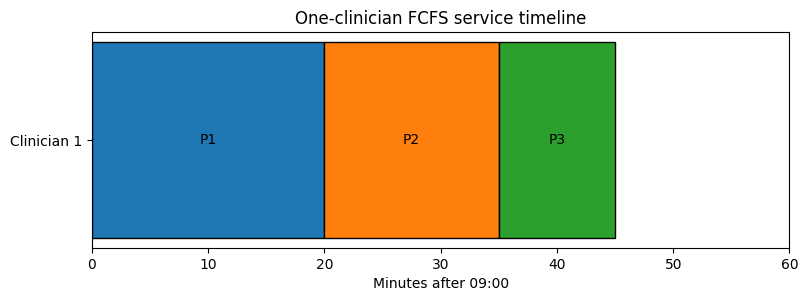

In [3]:
mean_wait = small_result["wait_min"].mean()
staffed_window = 60
utilization = small_result["service_duration_min"].sum() / staffed_window

print(f"Mean wait: {mean_wait:.1f} minutes")
print(f"Utilization during the stated 60-minute window: {utilization:.0%}")

fig, ax = plt.subplots(figsize=(9, 2.8))
for row in small_result.itertuples(index=False):
    ax.barh(
        y=f"Clinician {row.clinician}",
        width=row.service_duration_min,
        left=row.service_start_minute,
        height=0.35,
        edgecolor="black",
        label=row.patient_id,
    )
    ax.text(
        row.service_start_minute + row.service_duration_min / 2,
        f"Clinician {row.clinician}",
        row.patient_id,
        ha="center",
        va="center",
    )
ax.set(xlabel="Minutes after 09:00", title="One-clinician FCFS service timeline")
ax.set_xlim(0, 60)
plt.show()

P2 waits 15 minutes because the clinician is occupied until minute 20. P3 arrives at minute 25 but waits until P2 finishes at minute 35. The mean wait is ((0+15+10)/3=8.3) minutes.

The utilization calculation uses a stated 60-minute window. Busy time is 45 minutes, so utilization is 75%. If we instead divided by the 45 minutes from first start to final completion, we would report 100%; that is a different denominator and a different claim.

Try changing `n_clinicians` to 2. Waiting falls, but capacity use also falls. This is the central operational trade-off: unused capacity can look inefficient while providing resilience against uncertain demand.

## 6. Prediction is not a decision

Healthcare operations can use machine learning to estimate:

- probability of appointment non-attendance;
- number of requests expected tomorrow;
- consultation or procedure duration;
- bed demand or likely discharge workload; and
- probability that equipment will be unavailable.

The prediction must be connected to an explicit action:

```text
Past operational records
          ↓
Prediction at a defined time
          ↓
Policy with constraints and human oversight
          ↓
Changed workflow
          ↓
Access, waiting, workload, safety, and equity outcomes
```

A lower no-show prediction error does not establish that overbooking is safe. The policy can increase crowding when many patients attend. Likewise, a staffing forecast is useful only if it is available before staffing decisions and if staffing can actually be changed.

### Information availability and leakage

At the scheduling decision time, an estimated no-show probability may be available; the actual attendance outcome is not. Actual consultation duration is known only after the consultation ends. Using either future outcome to build tomorrow's schedule would be leakage.

Historical operational records also reflect previous policies. For example, observed consultation durations may be shorter on understaffed days because clinicians were rushed, not because patient needs were lower.

## 7. Simulation under uncertainty

### A simple definition of DES

**Discrete-Event Simulation (DES)** creates a virtual version of a real workflow and follows what happens whenever an important event occurs.

In a clinic, events include:

- a patient arriving;
- a patient joining a queue;
- a clinician becoming available;
- a consultation starting or finishing; and
- the clinic reaching its closing time.

It is called **discrete-event** because the simulated system changes at these particular event times. The simulation clock can move directly from one event to the next instead of recalculating every second when nothing changes.

```text
09:00  Patient P1 arrives and starts consultation
09:05  Patient P2 arrives and waits
09:20  P1 finishes; P2 starts
09:35  P2 finishes
```

In this example, the important events occur at 09:00, 09:05, 09:20, and 09:35. DES uses the workflow rules and resource availability to determine what happens at each event.

### What question does DES answer?

DES primarily supports **what-if questions**:

> What outcomes might occur if the same healthcare service used a different booking, staffing, capacity, or queue policy?

For example:

- What happens if the clinic books 32 rather than 30 patients?
- What happens if it leaves some capacity for urgent arrivals?
- What happens if another clinician is added during a busy period?
- How often might overtime occur when attendance and consultation times vary?

DES does not predict exactly what will happen on a particular future day. It estimates a range of possible outcomes under clearly stated assumptions.

### DES compared with ML and optimization

| Approach | Main question | Clinic example |
|---|---|---|
| Machine learning | What is likely to happen? | Predict whether a scheduled patient will attend. |
| Discrete-event simulation | What might happen as patients move through this workflow? | Estimate queues, waits, overtime, and resource use across possible clinic days. |
| Optimization | Which feasible decision best meets the agreed priorities? | Select a booking or staffing policy after considering access, waits, safety, and workload. |

These approaches can work together:

```text
Data or ML estimates
        ↓
DES evaluates possible workflow consequences
        ↓
Policy comparison or optimization evaluates the alternatives
        ↓
Accountable stakeholders make the final decision
```

ML is optional: a DES can use simple historical or assumed distributions without an ML model. Similarly, simulation does not automatically identify the best policy. It provides evidence about likely consequences that can be used during policy comparison.

### Representing uncertainty

A simulation needs explicit assumptions about:

1. attendance and arrival distributions;
2. service-duration distributions;
3. urgent demand;
4. resource availability;
5. queue discipline; and
6. what happens at closing time.

These assumptions are part of the model and must be documented. Synthetic simulation output cannot establish that a policy will work in a real clinic.

### Why repeat simulated days?

One simulated day may favor a policy by chance. Monte Carlo evaluation repeats the stochastic experiment with different random draws, then compares outcome distributions. The median describes a typical simulated day, while upper percentiles reveal high-demand days.

In the code below, `simulate_simple_clinic()` creates one possible clinic day. Running it repeatedly represents different combinations of no-shows, arrival times, consultation durations, and urgent demand.


In [ ]:
def simulate_simple_clinic(
    seed,
    scheduled_count=30,
    n_clinicians=2,
    urgent_rate=4,
    closing_minute=480,
):
    """Simulate one fictional outpatient-clinic day using an FCFS queue.

    The function creates scheduled and urgent patient arrivals, samples whether
    scheduled patients attend, gives each attending patient a variable service
    duration, and sends all arrivals through ``run_fcfs``. It returns summary
    measures for this one simulated day rather than the patient-level table.

    Parameters
    ----------
    seed : int
        Seed for NumPy's random-number generator. Reusing a seed reproduces the
        same fictional day, which makes policy comparisons and debugging easier.
    scheduled_count : int, default=30
        Number of appointment bookings made before no-shows are simulated.
    n_clinicians : int, default=2
        Number of identical clinicians who can serve patients simultaneously.
    urgent_rate : float, default=4
        Mean number of unscheduled urgent arrivals per day in the Poisson model.
        It is an average across simulated days, not the fixed number for one day.
    closing_minute : float, default=480
        Scheduled closing time measured in minutes after opening. The default is
        480 minutes, or an eight-hour day.

    Returns
    -------
    dict
        Daily operational measures: mean wait, 90th-percentile wait, overtime,
        urgent waits longer than 30 minutes, and completed visit count.

    Notes
    -----
    All distributions and policy limits are fictional teaching assumptions.
    They are not estimated clinical standards or staffing recommendations.
    """

    # Create a dedicated random-number generator for this simulated day.
    # Using ``default_rng`` avoids changing NumPy's global random state.
    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------------
    # 1. Construct the clinic's appointment-booking template.
    # ------------------------------------------------------------------
    # ``np.arange(0, 450, 30)`` gives 15 times measured from opening:
    # 0, 30, 60, ..., 420 minutes. Repeating each value twice represents
    # two nominal appointments at each 30-minute time point, for 30 bookings.
    template = np.repeat(np.arange(0, 450, 30), 2)

    if scheduled_count > len(template):
        # An overbooking policy needs more appointment times than the nominal
        # template provides. Sample existing times with replacement and append
        # them, so some time points receive more than two bookings.
        number_of_extra_bookings = scheduled_count - len(template)
        extra = rng.choice(
            template,
            size=number_of_extra_bookings,
            replace=True,
        )
        scheduled_times = np.concatenate([template, extra])
    else:
        # A reduced-booking policy uses only the requested number of template
        # entries. In this simplified example, taking the first entries reduces
        # bookings but does not explicitly reserve named slots during the day.
        scheduled_times = template[:scheduled_count]

    # ------------------------------------------------------------------
    # 2. Simulate attendance for scheduled patients.
    # ------------------------------------------------------------------
    # ``rng.random`` produces one value in [0, 1) for every booking. A patient
    # attends when the value is at least 0.15, giving each booking a fictional
    # 15% no-show probability and 85% attendance probability.
    show = rng.random(scheduled_count) >= 0.15

    # Build all booked appointments first. The Boolean ``show`` mask will then
    # retain only patients who actually arrive and therefore enter the queue.
    scheduled = pd.DataFrame(
        {
            # Prefix S distinguishes scheduled visits from urgent visits.
            "patient_id": [f"S{i:02d}" for i in range(scheduled_count)],
            "source": "scheduled",

            # Patients do not arrive exactly at their booked times. Add normally
            # distributed variation with mean 0 and standard deviation 8 minutes.
            # Negative simulated times are clipped to 0 so nobody arrives before
            # the beginning of the modeled observation window.
            "arrival_minute": np.maximum(
                0,
                scheduled_times + rng.normal(0, 8, scheduled_count),
            ),

            # Service times are positive and right-skewed: most consultations are
            # moderate, while a smaller number take longer. The log-normal draw
            # has median near 24 minutes and is clipped to the fictional range
            # of 8 to 60 minutes to avoid extreme simulated values.
            "service_duration_min": np.clip(
                rng.lognormal(np.log(24), 0.35, scheduled_count),
                8,
                60,
            ),
        }
    ).loc[show]

    # ------------------------------------------------------------------
    # 3. Generate unscheduled urgent arrivals.
    # ------------------------------------------------------------------
    # A Poisson draw makes the daily number variable. A Poisson distribution models 
    # how many times an event occurs during a fixed interval such as:
    # - Urgent patients arriving during one clinic day
    # - Emergency calls received in one hour    
    # 
    # With urgent_rate=4, four
    # is the long-run mean; a particular simulated day can have another count.
    urgent_count = rng.poisson(urgent_rate)

    urgent = pd.DataFrame(
        {
            # Prefix U distinguishes these records from scheduled visits.
            "patient_id": [f"U{i:02d}" for i in range(urgent_count)],
            "source": "urgent",

            # Urgent arrivals are spread uniformly from opening through minute
            # 420. Every instant in this interval is equally likely in this
            # deliberately simple model.
            "arrival_minute": rng.uniform(0, 420, urgent_count),

            # Urgent visits have a separate fictional service-time distribution:
            # median near 30 minutes, with values clipped to 10--75 minutes.
            "service_duration_min": np.clip(
                rng.lognormal(np.log(30), 0.35, urgent_count),
                10,
                75,
            ),
        }
    )

    # ------------------------------------------------------------------
    # 4. Send every attending patient through the clinic queue.
    # ------------------------------------------------------------------
    # Combine scheduled attendees and urgent arrivals. ``run_fcfs`` sorts the
    # combined table by actual arrival time, assigns each patient to the next
    # available clinician, and calculates start, completion, and waiting times.
    arrivals = pd.concat([scheduled, urgent], ignore_index=True)
    result = run_fcfs(arrivals, n_clinicians=n_clinicians)

    # ------------------------------------------------------------------
    # 5. Calculate operational outcomes for this simulated day.
    # ------------------------------------------------------------------
    # The last completion determines overtime. ``max(0, ...)`` ensures that a
    # day finishing before closing reports zero overtime rather than a negative
    # number. For example, completion at 510 with closing at 480 gives 30 minutes.
    final_completion_minute = result["completion_minute"].max()
    overtime = max(0.0, final_completion_minute - closing_minute)

    # Count urgent patients whose simulated waiting time exceeds 30 minutes.
    # The 30-minute value is a fictional review limit used to compare policies;
    # it should not be interpreted as a clinical standard.
    is_urgent = result["source"] == "urgent"
    waited_over_30_minutes = result["wait_min"] > 30
    urgent_wait_breaches = int((is_urgent & waited_over_30_minutes).sum())

    # Return one row's worth of summary measures. Repeating this function with
    # many seeds produces a distribution of outcomes across possible clinic days.
    return {
        "mean_wait_min": result["wait_min"].mean(),
        # 90th-percentile patient waiting time, measured in minutes
        "p90_wait_min": result["wait_min"].quantile(0.90),
        "overtime_min": overtime,
        "urgent_wait_breaches": urgent_wait_breaches,
        "visits": len(result),
    }


policies = {
    "baseline_30": {"scheduled_count": 30},
    "reserve_2": {"scheduled_count": 28},
    "overbook_2": {"scheduled_count": 32},
}

rows = []
for policy_name, settings in policies.items():
    # run 300 simulated days for each policy, using a different seed for each day
    for simulation_id in range(300):
        rows.append(
            {
                "policy": policy_name,
                "simulation_id": simulation_id,
                **simulate_simple_clinic(seed=10_000 + simulation_id, **settings),
            }
        )

simulation_results = pd.DataFrame(rows)
simulation_results.groupby("policy").agg(
    visits_median=("visits", "median"),
    mean_wait_median=("mean_wait_min", "median"),
    p90_wait_median=("p90_wait_min", "median"),
    overtime_p90=("overtime_min", lambda s: s.quantile(0.90)),
    urgent_breaches_mean=("urgent_wait_breaches", "mean"),
).round(1)

,visits_median,mean_wait_median,p90_wait_median,overtime_p90,urgent_breaches_mean
policy,,,,,
baseline_30,30.0,9.0,24.1,14.4,0.7
overbook_2,31.0,12.7,30.3,33.2,1.0
reserve_2,28.0,8.3,22.5,0.0,0.8


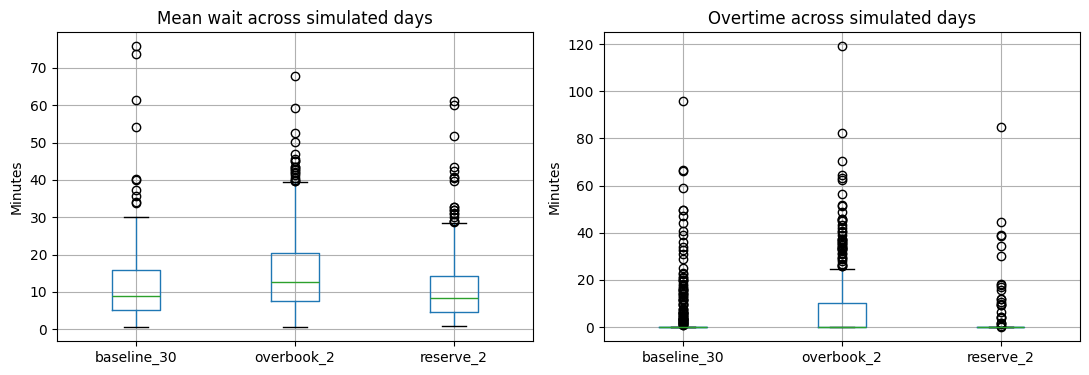

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
simulation_results.boxplot(column="mean_wait_min", by="policy", ax=axes[0])
simulation_results.boxplot(column="overtime_min", by="policy", ax=axes[1])
axes[0].set(title="Mean wait across simulated days", ylabel="Minutes", xlabel="")
axes[1].set(title="Overtime across simulated days", ylabel="Minutes", xlabel="")
plt.suptitle("")
plt.tight_layout()
plt.show()

The numbers above are consequences of the stated fictional distributions, not estimates for any real clinic. Interpret the pattern rather than searching for a universally best policy:

- reserving capacity may reduce waiting and overtime but schedule fewer routine appointments;
- overbooking may increase completed visits when no-shows occur but worsen crowding on high-attendance days; and
- the operational choice depends on which outcomes and constraints matter.

The demonstration processes all arrivals with FCFS. The lab adds predicted non-attendance, urgent-priority queues, subgroup comparisons, and explicit checks.

### Interpreting the simulation boxplots

Each policy was simulated for 300 fictional clinic days. The boxplots therefore show **variation across days**, not variation among individual patients within one day.

#### How to read a boxplot

- The line inside the box is the **median**, representing the middle simulated day.
- The bottom and top of the box are the 25th and 75th percentiles. The box contains the middle 50% of simulated days.
- The distance between those percentiles is the **interquartile range (IQR)**.
- The whiskers extend to typical values beyond the box, conventionally up to 1.5 times the IQR.
- Points beyond the whiskers are unusually high or low simulated days. They are not automatically data errors; they may represent plausible busy or disrupted days produced by the simulation.

Boxes at lower vertical positions represent lower values of the plotted outcome. A taller box indicates greater day-to-day variability. Overlapping boxes mean that policy outcomes are not completely separated: random attendance, arrival times, service durations, and urgent demand can sometimes matter as much as the policy choice.

#### Mean wait across simulated days

For each simulated day, the function first calculates:

```python
result["wait_min"].mean()
```

Thus, every value underlying this boxplot is the **mean patient wait for one day**. The plot does not show the distribution of all individual patient waiting times.

For example, if five patients wait 0, 5, 10, 15, and 20 minutes, that day contributes one value of 10 minutes to the boxplot. Repeating the simulation produces 300 daily mean-wait values for each policy.

The simulated quartiles are approximately:

| Policy | 25th percentile | Median | 75th percentile |
|---|---:|---:|---:|
| `reserve_2` | 4.7 min | 8.3 min | 14.3 min |
| `baseline_30` | 5.2 min | 9.0 min | 15.8 min |
| `overbook_2` | 7.6 min | 12.7 min | 20.4 min |

In this simulation, `reserve_2` has the lowest median daily mean wait, while `overbook_2` has the highest median and upper quartile. Overbooking creates more days with high average waits because more attending patients compete for the same clinicians. The boxes still overlap, so the result does not mean that every reserve-policy day is better than every baseline or overbooking day.

Mean waiting time should not be interpreted alone. A reasonable daily mean can conceal a few very long patient waits. The accompanying 90th-percentile wait and urgent-wait-breach measures help reveal those experiences.

#### Overtime across simulated days

For each day, overtime is calculated as:

```python
max(0, final_completion_minute - closing_minute)
```

If the clinic closes at minute 480 and the final consultation ends at minute 510, the simulated day has 30 minutes of overtime. A day finishing at or before minute 480 has zero overtime.

The simulated overtime summaries are approximately:

| Policy | Median | 75th percentile | 90th percentile | Days with no overtime |
|---|---:|---:|---:|---:|
| `reserve_2` | 0 min | 0 min | 0 min | 91.7% |
| `baseline_30` | 0 min | 0.2 min | 14.4 min | 75.0% |
| `overbook_2` | 0 min | 10.3 min | 33.2 min | 65.0% |

All three policies have median overtime of zero because more than half of their simulated days finish by closing. A zero median does **not** mean overtime never occurs. For example, the baseline policy has a 90th-percentile overtime of 14.4 minutes: approximately 90% of its simulated days have no more than 14.4 minutes of overtime, while the remaining 10% have more.

The reserve policy produces overtime least often. The overbooking policy produces it more frequently and creates a much heavier upper tail. Because many days have exactly zero overtime, an overtime box may appear compressed at zero. The boxplot should therefore be accompanied by the percentage of days with any overtime and an upper percentile such as P90.

#### What the two plots say together

Under these fictional assumptions:

- reserving capacity results in fewer scheduled bookings, generally shorter waits, and lower overtime risk;
- overbooking produces slightly more completed visits but generally longer waits and greater overtime risk; and
- the baseline policy lies between those alternatives.

This is a multi-objective trade-off, not proof that one policy is universally best. A real decision must also consider access, urgent-care performance, staff workload, patient experience, safety, equity, and whether the simulation assumptions match the clinic. Synthetic simulation results support policy discussion; they do not establish that a policy will work in clinical practice.


## 8. Optimization as policy comparison

In this notebook, **optimization** means comparing several possible clinic policies and choosing the one that provides the most acceptable balance of outcomes. It is not an ML model, and it does not mean that the computer automatically decides what the clinic should value.

A policy is a decision the clinic could implement. Our examples are:

- `reserve_2`: make 28 scheduled bookings and leave additional capacity;
- `baseline_30`: make the usual 30 scheduled bookings; and
- `overbook_2`: make 32 scheduled bookings to compensate for possible no-shows.

The simulation estimates what might happen under each policy across many possible clinic days. We then compare outcomes such as patients served, waiting time, overtime, and urgent waiting-time breaches.

### What is needed for a policy comparison?

| Element | Clinic example |
|---|---|
| Choices | Number of bookings, reserved capacity, or clinicians staffed |
| Desired outcomes | Shorter waits, less overtime, fewer urgent breaches, and adequate access |
| Non-negotiable limits | Staffing availability, shift length, room capacity, and safety requirements |
| Uncertainty | No-shows, arrival times, consultation duration, and urgent demand |

### Combining outcomes into a policy cost

When several outcomes matter, the clinic may summarize them using a combined policy cost:

$$
J=w_1(\text{mean wait})+w_2(\text{overtime})+w_3(\text{urgent breaches}).
$$

For each policy, we take its simulated waiting, overtime, and urgent-breach results. Each result is multiplied by a **weight** representing how important that outcome is, and the weighted values are added to calculate $J$.

A smaller $J$ means a lower overall policy cost according to those agreed priorities. It does not mean the policy is universally best.

For example:

- a larger $w_1$ places more importance on reducing patient waiting;
- a larger $w_2$ places more importance on avoiding staff overtime; and
- a larger $w_3$ places more importance on avoiding urgent waiting-time breaches.

Because minutes of waiting, minutes of overtime, and numbers of breaches are different kinds of measurements, they should be converted to a comparable scale or the weights should explicitly account for those differences before they are added.

### Who decides the weights?

The optimization algorithm does not automatically discover the correct values of $w_1$, $w_2$, and $w_3$. The weights are decided before comparing policies and represent value judgments about what matters.

They should be agreed using input from relevant stakeholders, such as:

- clinicians and safety teams;
- clinic and hospital operations staff;
- workforce representatives;
- patients or patient representatives; and
- finance and organizational leadership where appropriate.

Evidence such as staffing costs, service targets, patient feedback, and the consequences of delayed urgent care can inform the discussion. The selected weights and their justification should be documented.

It is also useful to repeat the comparison using several reasonable sets of weights. If a small change in weights produces a different winning policy, the decision is sensitive to stakeholder preferences and should not be presented as a certain technical answer.

### Apply constraints before comparing costs

Some requirements should not be traded away through a combined score. For example, a clinic may decide that a policy is unacceptable if it regularly produces excessive urgent delays or violates staffing limits.

A safer selection process is:

1. Define the candidate policies.
2. Simulate each policy across many possible days.
3. Reject policies that violate safety, staffing, or capacity requirements.
4. Compare the remaining policies using their individual outcomes.
5. Optionally calculate $J$ using the pre-agreed weights.
6. Check whether the recommendation changes under other reasonable assumptions or weights.
7. Let accountable stakeholders make the final policy decision.

Always display the component outcomes alongside $J$. A single score can hide an important problem—for example, a policy might have a good overall score but still create unacceptable urgent delays.

### What does “best policy” mean here?

There is no context-free best policy:

- `reserve_2` generally reduces waiting and overtime but offers fewer scheduled bookings;
- `overbook_2` may serve slightly more patients but increases congestion and overtime risk; and
- `baseline_30` provides a middle option under the current assumptions.

The preferred policy is therefore the one that satisfies the clinic's non-negotiable requirements and provides the most acceptable trade-off for its agreed priorities. Simulation supports that decision; it does not replace stakeholder judgment or real-world validation.


## 9. Safety, equity, and quality improvement

The World Health Organization describes quality health services as effective, safe, people-centred, timely, equitable, integrated, and efficient. Resource optimization therefore cannot mean cost minimization alone.

### Possible unintended consequences

- **Overbooking:** crowding and long waits when attendance is higher than expected.
- **High utilization targets:** little resilience when staff are absent or demand rises.
- **Priority queues:** excessive waits for people classified as lower urgency.
- **No-show prediction:** historical barriers such as distance or inflexible employment may become reasons to disadvantage the same patients again.
- **Duration prediction:** complex patients may be allocated too little time.
- **Aggregate averages:** poor service for a small subgroup may be hidden.

Protected attributes should not simply be removed and forgotten. They may be needed for auditing outcomes. Any use in the decision rule needs a justified purpose, appropriate governance, and context-specific legal and ethical review.

### From efficiency to quality improvement

Evaluate at least four dimensions:

| Dimension | Example measure |
|---|---|
| Access | Requests scheduled; visits started before closing |
| Timeliness | Median and 90th-percentile waiting time |
| Safety | Urgent wait breaches; escalation failures |
| Workforce | Overtime; workload distribution |
| Equity | Wait and access by relevant subgroup, with sample sizes |
| Efficiency | Utilization and idle capacity |

An observed difference is a signal to investigate. Small subgroup counts produce unstable estimates, and simulation assumptions may create the apparent disparity.

## 10. From prototype to monitored workflow

A real implementation would need more than a successful notebook.

### Validation before use

- Verify identifiers, timestamps, cancellations, and appointment/encounter linkage.
- Use time-based evaluation when the tool will support future scheduling.
- Evaluate predictions and downstream policies separately.
- Compare against current practice and simple baselines.
- Stress-test demand surges, staff absence, distribution shift, and missing inputs.
- Review results with patients, administrators, clinicians, and operational staff.

### Deployment controls

- Show the recommendation, assumptions, and capacity constraints.
- Allow authorized staff to override it and record the reason.
- Define an escalation path for urgent or exceptional cases.
- Never automatically deny access solely from a predicted no-show score.
- Document who is accountable for approving schedules.

### Monitoring

Monitor input drift, attendance calibration, waiting distributions, urgent breaches, overtime, overrides, and subgroup outcomes. A feedback loop matters: changing the schedule changes the future data used to retrain the model.

```text
Policy → workflow changes → new records → retraining data
   ↑                                      │
   └──────── monitoring and review ───────┘
```

## Limitations of this demonstration

- The patients, attendance probabilities, arrival patterns, and service durations are generated for teaching.
- The simulator omits rooms, breaks, staff roles, referrals, cancellations, and clinical complexity.
- FCFS is not an appropriate policy for every clinical service.
- A 30-minute urgent-wait threshold is an illustrative operational rule, not a clinical standard.
- The simulated comparisons cannot establish patient benefit, safety, or feasibility in a real organization.

The value of the demonstration is methodological: define the decision, use only information available at that time, compare policies across repeated uncertain scenarios, and examine several outcomes.

## Key takeaways

1. Healthcare operations concerns patient flow and resource-dependent work, not only financial administration.
2. Demand, capacity, and variability jointly determine waiting and workload.
3. Prediction estimates an uncertain quantity; a policy converts information into action; simulation estimates possible consequences.
4. High predictive accuracy or utilization does not prove operational benefit.
5. Policy evaluation must include access, tail waiting, safety, staff workload, uncertainty, and equity.
6. Synthetic simulations support learning and pre-deployment reasoning but cannot validate a real clinical service.

## 11. Review questions and further reading

### Review questions

1. Why can a queue form even when total daily workload is below total daily capacity?
2. Distinguish appointment time, arrival time, service-start time, and completion time.
3. Why is actual attendance unavailable to tomorrow's scheduling policy?
4. What different questions are answered by mean wait and 90th-percentile wait?
5. Give one benefit and one risk of reserving urgent capacity.
6. Why should component outcomes be reported even when an optimization score is used?
7. How could a no-show model reproduce an access barrier?
8. What would you monitor after deploying a scheduling recommendation tool?

### Glossary

| Term | Meaning |
|---|---|
| Discrete-event simulation | A model in which system state changes at event times |
| FCFS | First-Come, First-Served queue discipline |
| Queue discipline | Rule used to select the next waiting item for service |
| Non-preemptive priority | Priority affects the next selection but does not interrupt current service |
| Bottleneck | Resource or activity that constrains system flow |
| Utilization | Fraction of stated available resource time spent busy |
| Monte Carlo evaluation | Repeated random simulation used to characterize uncertainty |
| Policy | Rule that maps available information to an action |

### Core references

- World Health Organization. [Quality of care](https://www.who.int/health-topics/quality-of-care). Definitions of timely, equitable, integrated, and efficient health services.
- Little, J. D. C. (1961). [A Proof for the Queuing Formula: L = λW](https://doi.org/10.1287/opre.9.3.383). *Operations Research*, 9(3), 383–387.

### Optional further study

- Discrete-event simulation libraries such as SimPy.
- Linear and mixed-integer programming for staffing and scheduling.
- Process mining for discovering workflow patterns from event logs.
- Robust and stochastic optimization when decisions must perform across uncertain scenarios.